## Matrix-free rSVD adjoint
This notebook tests out the improved implementation of the `MatrixFreeRSVD` which uses LU or Cholesky factorization on $M_\partial = L U$ (with $U = L^T$ for Cholesky). By pre-computing these, solving
$$
M_\partial \tilde q_i = q_i
$$
can be done with forward and backward substitution.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
from fenics import UnitSquareMesh, FunctionSpace
from utils.utils import disk_cache, progress_bar

from algorithms.matrix_free_rsvd import MatrixFreeRSVD as MatrixFreeRSVDOld
from algorithms.rsvd_solvers import MatrixFreeRSVD

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
@disk_cache('../../results/precompute_experiments')
def experiment(N_range, k, repeat=1):
    record = []

    n_steps, step = len(N_range) * repeat, 1
    for N in N_range:
        n = round(np.sqrt(N))
        mesh = UnitSquareMesh(n, n)
        V_h = FunctionSpace(mesh, 'CG', 1)

        for _ in range(repeat):
            results = {'N': N}
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1
            
            # Old implementation
            t = time()
            MatrixFreeRSVDOld(V_h).mf_rsvd(k=k)
            results['old'] = time() - t

            # New implementation (LU)
            t = time()
            MatrixFreeRSVD(V_h, precompute='LU').solve(k=k)
            results['LU'] = time() - t

            # New implementation (Cholesky)
            t = time()
            MatrixFreeRSVD(V_h, precompute='Cholesky').solve(k=k)
            results['Cholesky'] = time() - t

            record.append(results)

    return pd.DataFrame(record)


In [3]:
N_range0 = np.linspace(10_000, 50_000, 21, dtype=int)
N_range1 = np.linspace(1000,   5000,   21, dtype=int)
repeat = 30
params = [
    {'N_range': N_range0, 'k': 25,  'repeat': repeat},
    {'N_range': N_range0, 'k': 100, 'repeat': repeat},
    {'N_range': N_range1, 'k': 10,  'repeat': repeat},
    {'N_range': N_range1, 'k': 25,  'repeat': repeat}
]
results = [{'params': p, 'df': experiment(**p)} for p in params]

[##############################] 630/630 [N=50,000]
[##############################] 630/630 [N=50,000]
[##############################] 630/630 [N=5,000]
[##############################] 630/630 [N=5,000]


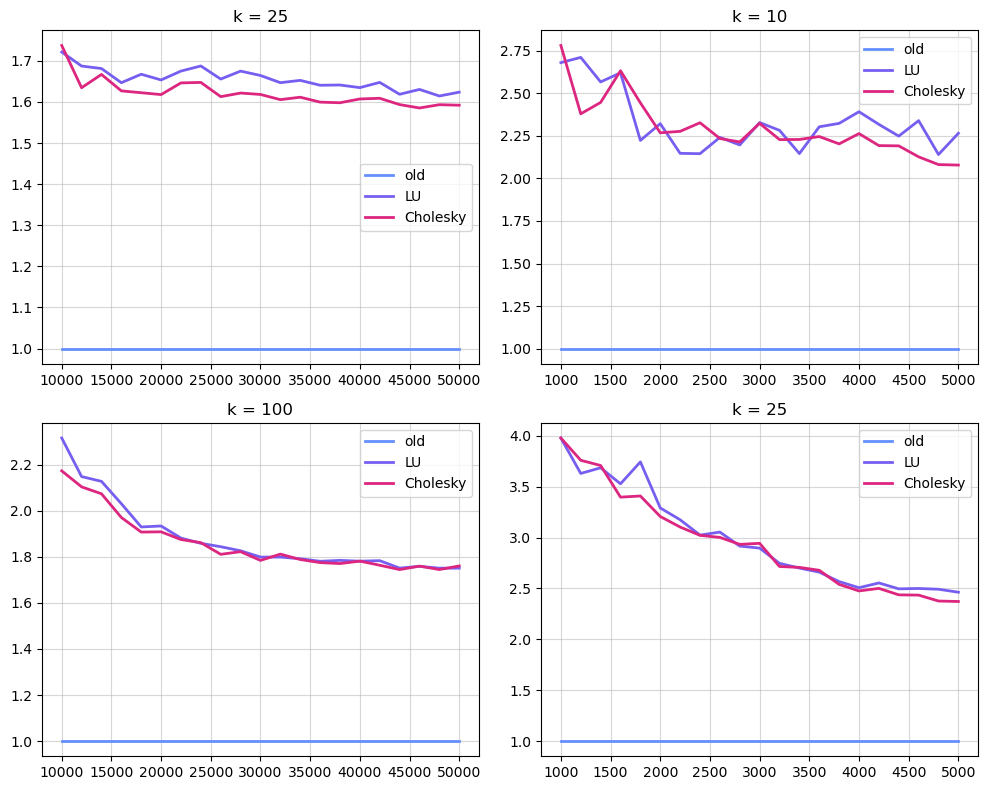

In [5]:
from utils.colors import C3
cols = ['old', 'LU', 'Cholesky']

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False)

for ax, result in zip(axes.T.flat, results):
    params = result['params']
    df = result['df'].groupby('N').agg('median').reset_index()
    
    for i, col in enumerate(cols):
        ax.plot(df.N, df['old'] / df[col], c=C3[i], lw=2, label=col)
    
    ax.set_title(f"k = {params['k']}")
    ax.legend()
    ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

